In [16]:
import os
import re
from pathlib import Path
from datetime import datetime
import numpy as np
import pandas as pd
import gc
import matplotlib.pyplot as plt 
import importnb
#import syn_gen function
with importnb.imports("ipynb"):
    from syn_gen import syn_gen 


processed_data_dir = Path('../Data/processed_daily_data')
keysite_label = "WSDC1"

In [17]:
# --------------------- Read in key inputs ----------------------------
ixx_hefs = np.load(processed_data_dir / "ixx_hefs.npy",allow_pickle=True)               # the initialization dates for HEFS
ixx_obs = np.load(processed_data_dir / "ixx_obs.npy",allow_pickle=True)                 # the dates for the obs
ixx_obs_forward = np.load(processed_data_dir / "ixx_obs_forward.npy",allow_pickle=True) # the dates for forward looking obs
hefs_forward = np.load(processed_data_dir / "hefs_forward.npy",allow_pickle=True)       # the forward-looking HEFS forecasts for all sites
obs_forward = np.load(processed_data_dir / "obs_forward.npy",allow_pickle=True)         # the forward-looking obs flows for all sites
obs_flows = pd.read_csv(processed_data_dir / "observed_flows.csv")    # matrix of observed flows


In [18]:
#9 seconds - could move to data_preprocessing to speed things up, but then lose flexibility to change length of obs_forward in optimization

#convert to datetime objects
ixx_obs = pd.to_datetime(ixx_obs)
ixx_hefs = pd.to_datetime(ixx_hefs)
ixx_obs_forward = pd.to_datetime(ixx_obs_forward)

n_obs, n_sites = obs_flows.shape
site_names = obs_flows.columns
n_hefs_sites, n_hefs, leads, n_ens = hefs_forward.shape       # (# sites, # HEFS dates, # leads, # ensemble members)


In [ ]:
#####THIS BLOCK NEEDS TO BE DELETED IN syn_gen, since all of these are arguments
seed = 1
kk      = 14
knn_pwr = -1.86
scale_pwr = 4.18
hi      = 6.52
lo      = 1.94
sig_a   = -3.15
sig_b   = 6

gen_start = ixx_obs_forward[0]
gen_end = ixx_obs_forward[-1]
fit_start = ixx_hefs[0]
fit_end = ixx_hefs[-1]

In [20]:
gen_start = pd.to_datetime(gen_start, utc=True)
gen_end = pd.to_datetime(gen_end, utc=True)
fit_start = pd.to_datetime(fit_start, utc=True)
fit_end = pd.to_datetime(fit_end, utc=True)

# generation period
ixx_gen = pd.date_range(gen_start, gen_end, freq="D", tz="UTC")
n_gen = len(ixx_gen)

# fit period
ixx_fit = pd.date_range(fit_start, fit_end, freq="D", tz="UTC")
n_fit = len(ixx_fit)

# Ensure fit dates lie within available obs_forward index
ixx_fit = ixx_fit[ixx_fit.isin(ixx_obs_forward)]

# HEFS dates that also have observed forward-looking data
mask_hefs_obs_fwd = ixx_hefs.isin(ixx_obs_forward)
ixx_hefs_obs_fwd = ixx_hefs[mask_hefs_obs_fwd]

In [21]:
#3 seconds

# ------------------------------------------------------------------
# Subset obs_forward arrays to simulation and fitting periods
# ------------------------------------------------------------------
# obs_forward for simulation dates (intersection with ixx_gen)
mask_gen = ixx_obs_forward.isin(ixx_gen)
obs_forward_gen = obs_forward[:, mask_gen, :]  # (n_sites, n_gen, leads)
n_gen_check = obs_forward_gen.shape[1]
if n_gen_check != n_gen:
    raise ValueError("obs_forward_gen time dimension does not match ixx_gen length")

# obs_forward for simulation dates (intersection with ixx_gen)
mask_fit = ixx_obs_forward.isin(ixx_fit)
obs_forward_fit = obs_forward[:,mask_fit,:]
n_fit_check = obs_forward_fit.shape[1]
if n_fit_check != n_fit:
    raise ValueError("obs_forward_gen time dimension does not match ixx_gen length")


# ------------------------------------------------------------------
# Subset hefs_forward array for resampling
# ------------------------------------------------------------------
# hefs_forward_resamp_sub: subset hefs_forward where ixx_hefs in ixx_obs_forward
hefs_forward_resamp_sub = hefs_forward[:,mask_hefs_obs_fwd,:, :]  # (n_sites,len(ixx_hefs_obs_fwd),leads,n_ens)

# Now subset further where ixx_hefs_obs_fwd in ixx_fit
mask_hefs_fit = np.isin(ixx_hefs_obs_fwd, ixx_fit)
hefs_forward_resamp = hefs_forward_resamp_sub[:,mask_hefs_fit,:, :]  # (n_sites,n_fit,leads,n_ens)


In [22]:
# ------------------------------------------------------------------
# Error checks
# ------------------------------------------------------------------
if kk < 1 or int(kk) != kk:
    raise ValueError("kk is not a valid positive integer")

if (ixx_gen[0] < ixx_obs_forward[0]) or (ixx_gen[-1] > ixx_obs_forward[-1]):
    raise ValueError("simulation period outside available observational period")

if (n_hefs_sites != n_sites):
    raise ValueError("# of hefs sites doesn't equal number of obs sites")

In [23]:
# ------------------------------------------------------------------
# KNN setup
# ------------------------------------------------------------------
# weights for neighbor ranks 1..kk
wts_raw = np.array([1.0 / k for k in range(1, kk + 1)], dtype=float)
wts = wts_raw / wts_raw.sum()

# decay weights across leads
w_leads = np.arange(1, leads + 1, dtype=float)
decay = (w_leads ** knn_pwr) / np.sum(w_leads ** knn_pwr)
decay

array([0.59213653, 0.16311957, 0.07673196, 0.04493557, 0.02967137,
       0.02113784, 0.01586863, 0.01237868, 0.00994331, 0.00817376,
       0.00684591, 0.00582297, 0.0050175 , 0.00437143, 0.00384496])

In [24]:
#5 seconds

# ------------------------------------------------------------------
# KNN distances (based on keysite only) - get distances
# ------------------------------------------------------------------
keysite = site_names == keysite_label
if np.sum(keysite)==0:
    raise ValueError("no site name matches keysite_label")

gen_knn_data = obs_forward_gen[keysite, :, :][-1,:,:].T  # (leads, n_gen)
fit_knn_data = obs_forward_fit[keysite, :, :][-1,:,:].T  # (leads, n_fit)

# knn_dist: shape (n_fit, n_gen)
knn_dist = np.empty((n_fit, n_gen), dtype=float)
for j in range(n_gen):
    diff = gen_knn_data[:, j][:, None] - fit_knn_data        # (leads, n_fit)
    knn_dist[:, j] = np.sqrt(np.sum(decay[:, None] * (diff ** 2), axis=0))



In [25]:
#6 seconds

# ------------------------------------------------------------------
# KNN distances (based on keysite only) - resample HEFS
# ------------------------------------------------------------------


# Resampled locations via KNN
# For each gen day, sample 1 index from nearest kk fits (0-based indices into n_fit)
knn_lst = np.empty(n_gen, dtype=int)
for j in range(n_gen):
    d = knn_dist[:, j].copy()
    # prevent zero-distance reuse
    d[d == 0.0] = np.nan
    valid = np.where(~np.isnan(d))[0]
    if valid.size < kk:
        raise ValueError("Not enough valid neighbors for KNN")
    sorted_valid = valid[np.argsort(d[valid])]
    neighbors = sorted_valid[:kk]
    # sample one neighbor with probabilities wts
    np.random.seed(seed)
    knn_lst[j] = np.random.choice(neighbors, p=wts)

# Resampled HEFS dates
hefs_resamp_vec = ixx_fit[knn_lst]

In [26]:
# ------------------------------------------------------------------
# Scale-decay function
# ------------------------------------------------------------------
def scale_decay_fun(hi, lo, pwr, lds):
    w = np.arange(1, lds + 1, dtype=float)
    if pwr != 0:
        win = w[::-1] #this just reverses w, i.e., 15, 14, ..., 1
        num = np.exp(pwr * win) - np.exp(pwr)
        den = np.exp(pwr * win[-2]) - np.exp(pwr)
        dcy = num / den
        dcy_out = dcy / dcy.max() * (hi - lo) + lo
    else:
        # linear from hi down to lo
        step = (hi - lo) / (len(w) - 1)
        dcy_out = hi - np.arange(len(w), dtype=float) * step
    return dcy_out

dcy = scale_decay_fun(hi, lo, scale_pwr, leads)

# sigmoid function
def sigmoid_fun(x, a, b):
    return 1.0 / (1.0 + np.exp(-(x * a + b)))

dcy

array([6.52      , 2.01006716, 1.94107192, 1.9400164 , 1.94000025,
       1.94      , 1.94      , 1.94      , 1.94      , 1.94      ,
       1.94      , 1.94      , 1.94      , 1.94      , 1.94      ])

In [27]:
# ------------------------------------------------------------------
# Simple Gaussian-like smoothing (approximate ksmooth with bandwidth=1)
# ------------------------------------------------------------------
def ksmooth_1d(x, bandwidth=1.0):
    if bandwidth <= 0:
        return x
    # discrete Gaussian kernel
    radius = int(3 * bandwidth)
    idx = np.arange(-radius, radius + 1, dtype=float)
    kernel = np.exp(-0.5 * (idx / bandwidth) ** 2)
    kernel /= kernel.sum()
    return np.convolve(x, kernel, mode="same")

In [28]:
#2.4 seconds

# ------------------------------------------------------------------
# Main scaling loop over sites
# ------------------------------------------------------------------
        
# Final array for synthetic ensemble forecasts
final_synthetic_forecasts = np.full((n_sites, n_gen, leads, n_ens), np.nan, dtype=float)
HEFS_scale_original_out = np.full((n_sites, n_gen, leads), np.nan, dtype=float)
HEFS_scale_capped_out = np.full((n_sites, n_gen, leads), np.nan, dtype=float)
HEFS_scale_out = np.full((n_sites, n_gen, leads), np.nan, dtype=float)

for j in range(n_sites):

    # gen_scale, fit_scale: (n_gen, leads)
    gen_scale = obs_forward_gen[j, :, :].copy()
    fit_scale = obs_forward_fit[j, knn_lst, :].copy()

    # Replace zeros with smallest positive in gen_scale
    pos_gen = gen_scale[gen_scale > 0.0]
    if pos_gen.size == 0:
        min_pos = 1.0
    else:
        min_pos = pos_gen.min()

    gen_scale[gen_scale == 0.0] = min_pos
    fit_scale[fit_scale == 0.0] = min_pos

    HEFS_scale = gen_scale / fit_scale  # (n_gen, leads)
    HEFS_scale_original_out[j,:,:] = HEFS_scale

    for k in range(leads):
        col = HEFS_scale[:, k].copy()
        # handle NaN, Inf, and zeros
        invalid = np.isnan(col) | np.isinf(col) | (col == 0.0)
        col[invalid] = 1.0

        # obs_sc for scaling thresholds
        obs_sc = obs_forward_gen[j, :, k].copy()
        pos_obs = obs_sc[obs_sc > 0.0]
        if pos_obs.size == 0:
            min_obs = 1.0
        else:
            min_obs = pos_obs.min()
        obs_sc[obs_sc <= 0.0] = min_obs
        obs_sc = np.log(obs_sc)

        # standardized obs (like R's scale)
        mu = obs_sc.mean()
        sd = obs_sc.std(ddof=1)
        if sd == 0.0 or np.isnan(sd):
            obs_scale = np.zeros_like(obs_sc)
        else:
            obs_scale = (obs_sc - mu) / sd

        ratio_threshold = sigmoid_fun(obs_scale, sig_a, sig_b) * (dcy[k] - 1.0) + 1.0
        # cap scaling ratios at threshold
        exceed = col > ratio_threshold
        col[exceed] = ratio_threshold[exceed]

        HEFS_scale[:, k] = col

    HEFS_scale_capped_out[j, :, :] = HEFS_scale
    # Smooth across leads for each generation time
    HEFS_scale_sm = np.empty_like(HEFS_scale)
    for t in range(n_gen):
        HEFS_scale_sm[t, :] = ksmooth_1d(HEFS_scale[t, :], bandwidth=1)

    # Apply scaling to each ensemble member
    # hefs_forward_resamp[j, knn_lst, :, e] has shape (n_gen, leads)
    for e in range(n_ens):
        final_synthetic_forecasts[j, :, :, e] = hefs_forward_resamp[j, knn_lst, :, e] * HEFS_scale_sm

    HEFS_scale_out[j, :, :] = HEFS_scale_sm




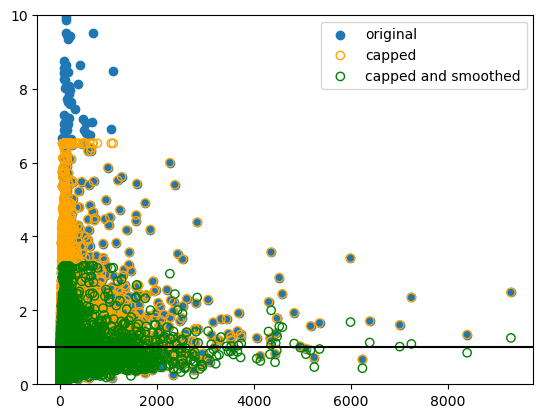

target date 1997-01-01 00:00:00+00:00
obs flow on target date
4475    5996.232325
Name: LAMC1F, dtype: float64
obs_forward for target date
[[[5996.232325   1444.366225    679.98249292  490.32747958  420.20374333
    380.06499042  347.560405    322.51791125  301.73040708  281.04916
    261.24291042  244.83541     228.08624333  218.00957708  208.53165958]]]
resampled obs_forward for target date
[[[1756.8487125  1362.78162167  612.31206     510.78207375  541.67665292
    402.75624     360.34457292  762.76329625 1194.86622583  509.54289958
   1161.05997083  679.04122625  401.48540583  330.08789917  397.34540708]]]
resampled date used for hefs resampling
DatetimeIndex(['2006-03-06 00:00:00+00:00'], dtype='datetime64[ns, UTC]', freq=None)
original scaling for target date
[[[3.41306129 1.05986623 1.11051625 0.95995436 0.77574646 0.94366009
   0.96452238 0.4228283  0.25252233 0.55157114 0.2250038  0.36056045
   0.56810594 0.66045916 0.52481205]]]
capped scaling for target date
[[[3.41306129 1.

In [ ]:
selected_site = 7 #7 is Lake Mendocino, 11 is Lake Sonoma

cur_lead = 0
ob = obs_forward[selected_site,:,cur_lead]
scale1 = HEFS_scale_original_out[selected_site,:,cur_lead]      #WSDC1
scale2 = HEFS_scale_capped_out[selected_site,:,cur_lead]      #WSDC1
scale3 = HEFS_scale_out[selected_site,:,cur_lead]      #WSDC1

plt.scatter(ob,scale1,label="original")
plt.scatter(ob,scale2,label='capped',facecolors='none',edgecolor='orange')
plt.scatter(ob,scale3,label = 'capped and smoothed',facecolors='none',edgecolor='green')
plt.ylim(0,10)
plt.axhline(1,color='k')
plt.legend()
plt.show()

#selected extreme flow event ('remember - all dates have been shifted forward 1 day to align with USACE convention')
targ_date = pd.to_datetime("1997-01-02",utc=True)
print(f"target date {targ_date}")

print('obs flow on target date')
print(obs_flows.iloc[ixx_obs==targ_date,selected_site])

gen_scale = obs_forward_gen[selected_site, :, :].copy()
fit_scale = obs_forward_fit[selected_site, knn_lst, :].copy()
my_loc = np.argwhere(ixx_gen == targ_date)
print("obs_forward for target date")
print(gen_scale[my_loc,:])
print("resampled obs_forward for target date")
print(fit_scale[my_loc,:])
print("resampled date used for hefs resampling")
print(ixx_fit[knn_lst[my_loc][0]])

print('original scaling for target date')
print(HEFS_scale_original_out[selected_site,np.argwhere(ixx_gen == targ_date),:])

print('capped scaling for target date')
print(HEFS_scale_capped_out[selected_site,np.argwhere(ixx_gen == targ_date),:])

print('capped and smoothed scaling for target date')
print(HEFS_scale_out[selected_site,np.argwhere(ixx_gen == targ_date),:])


In [30]:
# Clean up big intermediates (optional)
#del hefs_forward_resamp, hefs_forward_resamp_sub
#del obs_forward_fit, obs_forward_gen
#gc.collect()
